Ts = 0.00999999999999801
torch.Size([40, 200, 16])
test dataloader shape: torch.Size([40, 200, 16])


/home/a/.local/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


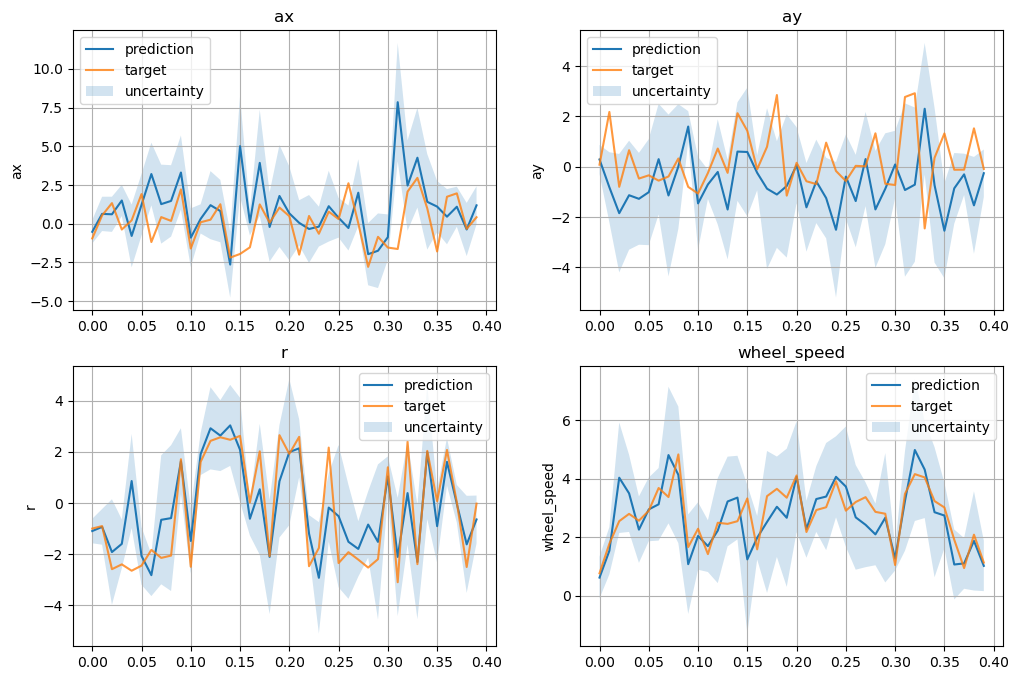

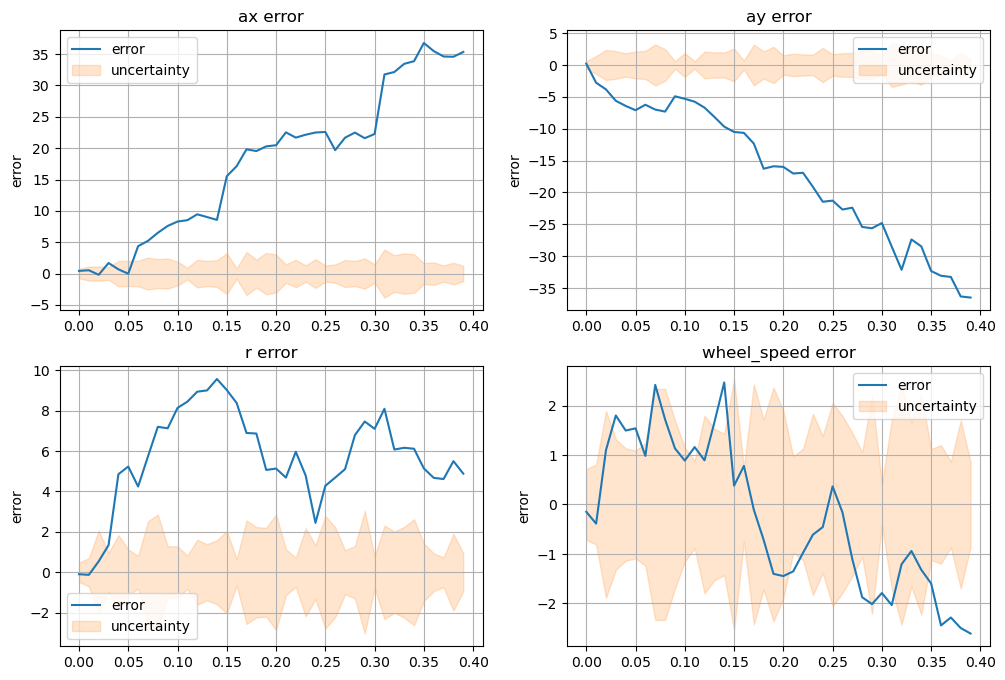

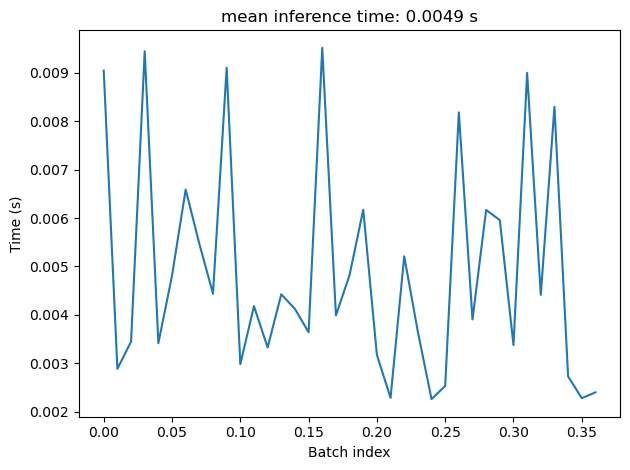

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import torch
from sensor_models.sensor_refine_model import TCNGaussian
from sensor_models.sensor_dataset import SensorDataset
from utils.argparser import get_parser




# def parse_args():
#     parser = get_parser()
#     return parser.parse_args()

# args = parse_args()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths and logging setup
df = pd.read_csv('/home/a/Learning-dynamics-models-for-velocity-estimation/code_my/opti_test/hoons_all_test.csv', index_col=0)
timestamp = time.strftime('%m-%d_%H-%M')


# Create the dataset
test_dataset = SensorDataset(
    df,
    subsample_all=1,
    Ts_multiplier=1,
    check_new_run=True,
    test_run_id=[],
    test=False,
    dtype=torch.float32,
    device=device,
    dataset_scaler=1.0,
    sequence_length=200,
)
test_data_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1, shuffle=False
)

print(f"test dataloader shape: {test_dataset.batches.shape}")


#create the model
model = TCNGaussian(
     input_size=4,
    output_size=4,
    num_channels=256,
    num_levels=4,
    kernel_size=2,
    dropout=0.2,
    # activation=torch.nn.ReLU,
    activation=torch.nn.SiLU,
    eps=1e-3
)
model.to(device)



# Load the model state dict
model_state_dict = torch.load('/home/a/Learning-dynamics-models-for-velocity-estimation/code_my/trained_models/05-12_19-37/best_epoch_2384_loss_1.6559.pt')

model.load_state_dict(model_state_dict)
model.eval()

count = 0
results = []
infer_times = []
integrate_error = np.zeros(4)

model.eval()
with torch.no_grad():
    for batch in test_data_loader:
        imu = batch[:,7:10,:]
        wheel = batch[:,3:4,:]
        inputs = torch.cat((imu, wheel), dim=1).to(device)
        time0 =time.time()
        mu, var = model(inputs)
        time1 = time.time()
        
        targets = batch[:, -4:, -1]
        
        mu = mu.cpu().numpy().flatten()
        var = var.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()
        
        uncertainty = np.sqrt(var)
        
        error= (mu - targets)
        integrate_error = np.add(integrate_error, error)
    
        
        results.append({
            'prediction': mu,
            'target': targets,
            'error':error,
            'uncertainty': uncertainty,
            'integrate_error': integrate_error,
            
        })
        if count >2:
            infer_times.append(time1 - time0)
        count += 1

#plot the results
#[ax,ay,r,wheel_speed]

# Define your metrics in order
metrics = ['ax', 'ay', 'r', 'wheel_speed']

# Create a 2×2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flat  # flatten to a 1D iterator

# Prepare your data once
times = np.arange(0, len(results) * 0.01, 0.01).tolist()

# Loop over each metric/index
for idx, (ax, metric) in enumerate(zip(axs, metrics)):
    preds = [res['prediction'][idx] for res in results]
    targs = [res['target'][idx]     for res in results]
    uncs  = [res['uncertainty'][idx] for res in results]

    ax.set_title(metric)
    # ax.set_xlabel('time')
    ax.set_ylabel(metric)

    ax.plot(times, preds, label='prediction')
    ax.plot(times, targs, alpha=0.8 ,label='target')
    ax.fill_between(
        times,
        [p - u for p, u in zip(preds, uncs)],
        [p + u for p, u in zip(preds, uncs)],
        alpha=0.2,
        label='uncertainty'
    )
    ax.legend()
    ax.grid()
    
fig, axs_2 = plt.subplots(2, 2, figsize=(12, 8))
axs_2 = axs_2.flat  # flatten to a 1D iterator

for idx, (ax_2, metric) in enumerate(zip(axs_2, metrics)):
    # errs = [res['error'][idx] for res in results]
    errs= [res['integrate_error'][idx] for res in results]
    uncs = [res['uncertainty'][idx] for res in results]
    
    ax_2.set_title(f'{metric} error')
    # ax_2.set_xlabel('time')
    ax_2.set_ylabel('error')
    ax_2.plot(times, errs, label='error')
    # ax_2.plot(times, uncs, label='uncertainty')
    ax_2.fill_between(
        times,
        [u for u in uncs],
        [-u for u in uncs],
        alpha=0.2,
        label='uncertainty',
        color='C1'
    )
    ax_2.legend()
    ax_2.grid()

times = np.arange(0, len(infer_times) * 0.01, 0.01).tolist()

plt.figure()
plt.plot(times, infer_times)
plt.title(f'mean inference time: {np.mean(infer_times):.4f} s')
plt.xlabel('Batch index')
plt.ylabel('Time (s)')


plt.tight_layout()
plt.show()
    

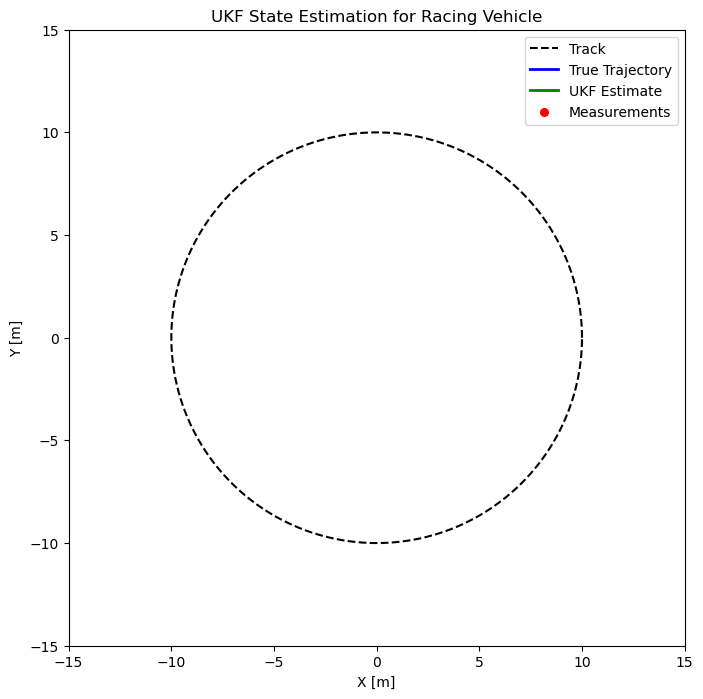